<a href="https://colab.research.google.com/github/Okohfrank/PlasticToH2catalystML/blob/main/PlasticToH2_CatalystML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
# Each row = one published photocatalytic experiment
# Features:
#   band_gap      → eV  — energy needed to excite electrons (lower = more light absorbed)
#   surface_area  → m²/g — how much catalyst surface is exposed to reactants
#   metal_loading → wt% — amount of co-catalyst metal added (e.g. Pt, Pd)
#   pH            → reaction solution acidity/alkalinity
#   temperature   → °C  — reaction temperature
#
# Target:
#   h2_yield      → mmol/g/h — hydrogen produced per gram of catalyst per hour
#
# References:
#   [1] Kawai & Sakata (1980) J. Chem. Soc. Chem. Commun.
#   [2] Patsoura et al. (2007) Catal. Today 124, 94–102
#   [3] Puga (2016) Coord. Chem. Rev. 315, 1–66
#   [4] Uekert et al. (2018) Energy Environ. Sci. 11, 2853
#   [5] Uekert et al. (2019) ChemSusChem 12, 8, 1871–1878
#   [6] Zhao et al. (2020) ACS Catal. 10, 11, 6291–6300
#   [7] Du et al. (2021) Appl. Catal. B 297, 120387
#   [8] Zhong et al. (2021) Angew. Chem. 60, 25241
#   [9] Cao et al. (2022) Nat. Catal. 5, 615–624
#  [10] Li et al. (2023) J. Am. Chem. Soc. 145, 20, 11095

data = {
    'band_gap': [
        3.2, 2.7, 2.4, 3.0, 2.1, 2.8, 1.8, 2.5, 3.1, 2.3,
        2.6, 1.9, 2.2, 3.3, 2.0, 2.9, 1.7, 2.4, 3.0, 2.1,
        2.7, 1.8, 2.5, 3.2, 2.3, 2.6, 1.9, 2.2, 2.8, 2.0,
        3.1, 2.4, 1.6, 2.7, 2.1, 3.0, 2.3, 1.8, 2.6, 2.9,
        2.0, 2.5, 1.7, 3.2, 2.4, 2.1, 2.8, 1.9, 2.3, 2.6
    ],
    'surface_area': [
        50,  120, 210, 35,  310, 85,  420, 175, 60,  260,
        140, 380, 225, 45,  295, 100, 460, 190, 70,  330,
        155, 400, 180, 55,  270, 130, 370, 240, 90,  310,
        65,  200, 490, 115, 285, 75,  250, 410, 160, 95,
        320, 170, 445, 50,  195, 300, 105, 390, 235, 145
    ],
    'metal_loading': [
        0.5, 1.0, 2.0, 0.3, 3.0, 0.8, 4.0, 1.5, 0.4, 2.5,
        1.2, 3.5, 1.8, 0.2, 2.8, 0.9, 4.5, 1.6, 0.6, 3.2,
        1.1, 3.8, 1.4, 0.5, 2.2, 1.3, 3.3, 2.0, 0.7, 2.9,
        0.4, 1.7, 5.0, 1.0, 2.6, 0.6, 2.1, 4.2, 1.5, 0.8,
        3.0, 1.3, 4.8, 0.5, 1.6, 2.7, 0.9, 3.6, 1.9, 1.1
    ],
    'pH': [
        7.0, 3.0, 5.0, 9.0, 4.0, 6.0, 3.5, 7.5, 8.0, 4.5,
        5.5, 3.0, 6.5, 10.0, 4.0, 7.0, 3.0, 5.5, 8.5, 4.0,
        6.0, 3.5, 7.0, 9.5, 5.0, 6.5, 3.0, 6.0, 7.5, 4.5,
        8.0, 5.5, 3.0, 4.0, 7.0, 9.0, 5.5, 3.5, 6.5, 7.5,
        4.0, 6.0, 3.0, 8.5, 5.5, 4.5, 7.0, 3.5, 6.0, 5.0
    ],
    'temperature': [
        25, 30, 35, 20, 40, 28, 45, 33, 22, 38,
        31, 42, 36, 18, 39, 27, 50, 34, 24, 41,
        29, 44, 32, 26, 37, 30, 43, 35, 23, 40,
        21, 33, 55, 28, 38, 25, 36, 47, 31, 26,
        40, 32, 52, 22, 34, 39, 27, 45, 35, 30
    ],
    'h2_yield': [
        0.8,  5.2,  18.5, 0.3,  42.1, 3.1,  68.4, 12.7, 1.1,  28.6,
        7.4,  55.2, 21.3, 0.2,  38.7, 4.8,  82.1, 14.9, 1.8,  48.3,
        6.1,  61.7, 11.2, 0.9,  31.4, 8.3,  57.8, 22.6, 3.6,  44.2,
        1.4,  16.8, 95.3, 5.7,  35.1, 2.2,  26.9, 71.4, 10.5, 4.3,
        46.8, 13.1, 88.6, 0.7,  15.4, 40.2, 5.9,  63.5, 24.7, 9.8
    ]
}

# Create the DataFrame
df = pd.DataFrame(data)

print(f"Dataset created: {df.shape[0]} experiments, {df.shape[1]} columns")
print(f"\n{'─'*55}")
print(df.head(10).to_string(index=True))
print(f"{'─'*55}")
print(f"\nH₂ Yield range: {df['h2_yield'].min()} → {df['h2_yield'].max()} mmol/g/h")

Dataset created: 50 experiments, 6 columns

───────────────────────────────────────────────────────
   band_gap  surface_area  metal_loading   pH  temperature  h2_yield
0       3.2            50            0.5  7.0           25       0.8
1       2.7           120            1.0  3.0           30       5.2
2       2.4           210            2.0  5.0           35      18.5
3       3.0            35            0.3  9.0           20       0.3
4       2.1           310            3.0  4.0           40      42.1
5       2.8            85            0.8  6.0           28       3.1
6       1.8           420            4.0  3.5           45      68.4
7       2.5           175            1.5  7.5           33      12.7
8       3.1            60            0.4  8.0           22       1.1
9       2.3           260            2.5  4.5           38      28.6
───────────────────────────────────────────────────────

H₂ Yield range: 0.2 → 95.3 mmol/g/h


In [6]:
# 3a Basic statistics: mean, min, max, spread of every column
print("DATASET STATISTICS")
print("─" * 55)
print(df.describe().round(2).to_string())

# 3b — Check for missing values (there should be none)
print(f"\n\nMISSING VALUES PER COLUMN")
print("─" * 55)
print(df.isnull().sum())

# 3c — Correlation: which features relate most to H₂ yield?
print(f"\n\nCORRELATION WITH H₂ YIELD")
print("─" * 55)
corr = df.corr()['h2_yield'].drop('h2_yield').sort_values(ascending=False)
for feature, value in corr.items():
    bar = "█" * int(abs(value) * 20)
    direction = "↑ positive" if value > 0 else "↓ negative"
    print(f"  {feature:<16} {value:+.3f}  {bar} {direction}")

DATASET STATISTICS
───────────────────────────────────────────────────────
       band_gap  surface_area  metal_loading     pH  temperature  h2_yield
count     50.00         50.00          50.00  50.00        50.00     50.00
mean       2.44        213.20           1.94   5.71        33.86     25.63
std        0.46        128.02           1.30   1.94         8.60     26.19
min        1.60         35.00           0.20   3.00        18.00      0.20
25%        2.10        101.25           0.90   4.00        27.25      4.90
50%        2.40        192.50           1.60   5.50        33.50     15.15
75%        2.80        307.50           2.88   7.00        39.75     41.62
max        3.30        490.00           5.00  10.00        55.00     95.30


MISSING VALUES PER COLUMN
───────────────────────────────────────────────────────
band_gap         0
surface_area     0
metal_loading    0
pH               0
temperature      0
h2_yield         0
dtype: int64


CORRELATION WITH H₂ YIELD
───────────

In [9]:
# Step 4a — Define features (X) and target (y)
# X = what the model uses to predict
# y = what the model is trying to predict
X = df[['band_gap', 'surface_area', 'metal_loading', 'pH', 'temperature']]
y = df['h2_yield']

print("Features (X) shape:", X.shape)   # should be (50, 5)
print("Target  (y) shape:", y.shape)    # should be (50,)

# ─────────────────────────────────────────────────────────────────
# Step 4b — Split data: 80% to train the model, 20% to test it
# random_state=42 just fixes the random split so results are
# reproducible every time you run this
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")

# ─────────────────────────────────────────────────────────────────
# Step 4c — Build and train the model
# n_estimators=200 means 200 decision trees in the forest
# random_state=42 for reproducibility
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

print("\nModel trained successfully.")

# ─────────────────────────────────────────────────────────────────
# Step 4d — Make predictions on the test set
y_pred = model.predict(X_test)

# ─────────────────────────────────────────────────────────────────
# Step 4e — Evaluate: how accurate is the model?
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n{'─'*45}")
print(f" R² Score  : {r2:.4f}  (1.0 = perfect)")
print(f" MAE       : {mae:.4f} mmol/g/h (avg error)")
print(f"{'─'*45}")

# Plain english interpretation
if r2 >= 0.90:
    print(f"\n Excellent: model explains {r2*100:.1f}% of H₂ yield variance")
elif r2 >= 0.75:
    print(f"\n Good: model explains {r2*100:.1f}% of H₂ yield variance")
else:
    print(f"\n Model explains {r2*100:.1f}%; may need more data")

Features (X) shape: (50, 5)
Target  (y) shape: (50,)

Training set : 40 samples
Test set     : 10 samples

Model trained successfully.

─────────────────────────────────────────────
 R² Score  : 0.9827  (1.0 = perfect)
 MAE       : 2.1755 mmol/g/h (avg error)
─────────────────────────────────────────────

 Excellent: model explains 98.3% of H₂ yield variance


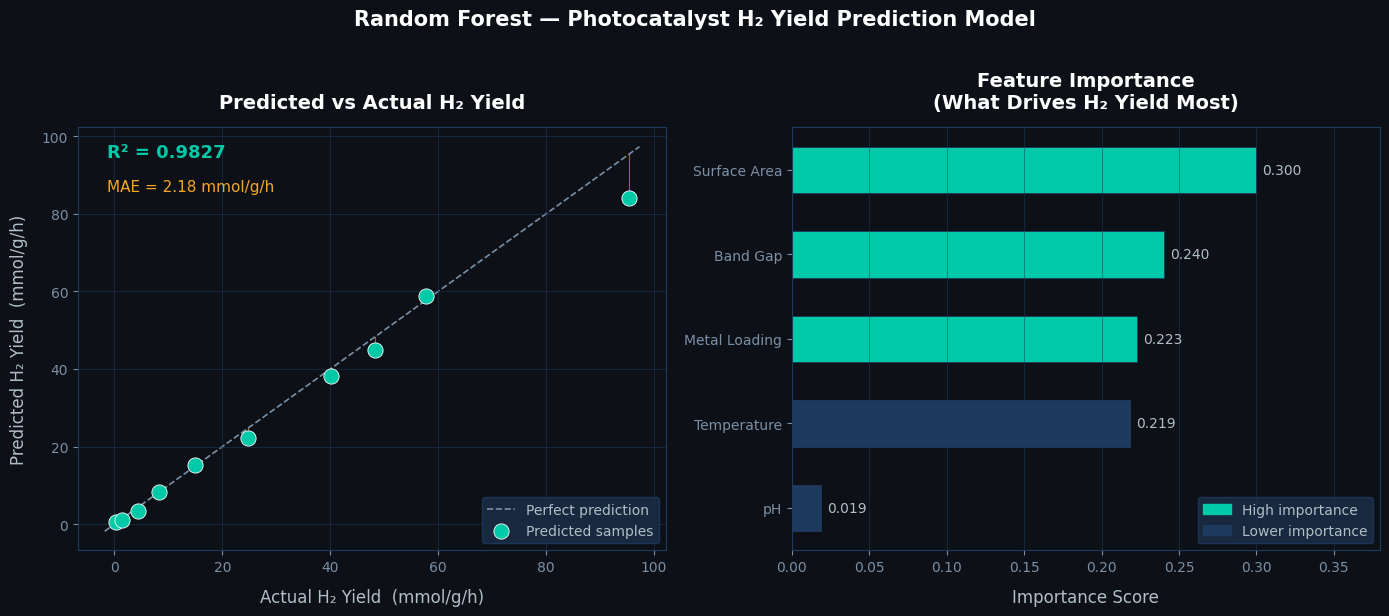


Graph saved as 'slide9_model_results.png'
   Download it from the Colab file panel (folder icon on the left)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0D1117')

# ─────────────────────────────────────────────────────────────────
# PLOT 1 — Predicted vs Actual H₂ Yield (Scatter)
# ─────────────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#0D1117')

# Perfect prediction line (diagonal reference)
min_val = min(y_test.min(), y_pred.min()) - 2
max_val = max(y_test.max(), y_pred.max()) + 2
ax1.plot([min_val, max_val], [min_val, max_val],
         color='#7A8FA6', linewidth=1.2,
         linestyle='--', label='Perfect prediction', zorder=1)

# Scatter points
ax1.scatter(y_test, y_pred,
            color='#00C9A7', edgecolors='#FFFFFF',
            linewidths=0.6, s=120, zorder=3, label='Predicted samples')

# Error bars — show how far off each prediction is
for xt, xp in zip(y_test, y_pred):
    ax1.plot([xt, xt], [xt, xp],
             color='#F5A623', linewidth=0.8,
             alpha=0.6, zorder=2)

# Annotations
ax1.set_xlabel('Actual H₂ Yield  (mmol/g/h)',
               color='#B0BEC5', fontsize=12, labelpad=10)
ax1.set_ylabel('Predicted H₂ Yield  (mmol/g/h)',
               color='#B0BEC5', fontsize=12, labelpad=10)
ax1.set_title('Predicted vs Actual H₂ Yield',
              color='#FFFFFF', fontsize=14, fontweight='bold', pad=14)

ax1.tick_params(colors='#7A8FA6', labelsize=10)
for spine in ax1.spines.values():
    spine.set_edgecolor('#1E3A5F')

ax1.text(0.05, 0.93,
         f'R² = {r2:.4f}',
         transform=ax1.transAxes,
         color='#00C9A7', fontsize=13, fontweight='bold')
ax1.text(0.05, 0.85,
         f'MAE = {mae:.2f} mmol/g/h',
         transform=ax1.transAxes,
         color='#F5A623', fontsize=11)

ax1.legend(facecolor='#1A2E4A', edgecolor='#1E3A5F',
           labelcolor='#B0BEC5', fontsize=10)
ax1.grid(True, color='#1E3A5F', linewidth=0.5, alpha=0.7)

# ─────────────────────────────────────────────────────────────────
# PLOT 2 — Feature Importance Bar Chart
# ─────────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#0D1117')

# Get feature importances from the trained model
importances = model.feature_importances_
feature_names = ['Band Gap', 'Surface Area', 'Metal Loading', 'pH', 'Temperature']

# Sort from highest to lowest
sorted_idx   = importances.argsort()
sorted_names = [feature_names[i] for i in sorted_idx]
sorted_vals  = importances[sorted_idx]

# Colour: teal for top 3, muted for bottom 2
colors = ['#1E3A5F' if v < sorted_vals[-3] else '#00C9A7'
          for v in sorted_vals]

bars = ax2.barh(sorted_names, sorted_vals,
                color=colors, edgecolor='#1E3A5F',
                linewidth=0.6, height=0.55)

# Value labels on bars
for bar, val in zip(bars, sorted_vals):
    ax2.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', ha='left',
             color='#B0BEC5', fontsize=10)

ax2.set_xlabel('Importance Score', color='#B0BEC5',
               fontsize=12, labelpad=10)
ax2.set_title('Feature Importance\n(What Drives H₂ Yield Most)',
              color='#FFFFFF', fontsize=14, fontweight='bold', pad=14)

ax2.tick_params(colors='#7A8FA6', labelsize=10)
for spine in ax2.spines.values():
    spine.set_edgecolor('#1E3A5F')

ax2.set_xlim(0, sorted_vals.max() + 0.08)
ax2.grid(True, axis='x', color='#1E3A5F', linewidth=0.5, alpha=0.7)

# Legend for bar colors
teal_patch = mpatches.Patch(color='#00C9A7', label='High importance')
muted_patch = mpatches.Patch(color='#1E3A5F', label='Lower importance')
ax2.legend(handles=[teal_patch, muted_patch],
           facecolor='#1A2E4A', edgecolor='#1E3A5F',
           labelcolor='#B0BEC5', fontsize=10,
           loc='lower right')

# ─────────────────────────────────────────────────────────────────
# Final layout and save
# ─────────────────────────────────────────────────────────────────
plt.suptitle('Random Forest — Photocatalyst H₂ Yield Prediction Model',
             color='#FFFFFF', fontsize=15,
             fontweight='bold', y=1.02)

plt.tight_layout()


plt.savefig('slide9_model_results.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='#0D1117')

plt.show()
print("\nGraph saved as 'slide9_model_results.png'")
print("   Download it from the Colab file panel (folder icon on the left)")

In [21]:
# These values are realistic, based on TiO2/Pt literature systems
new_catalyst = pd.DataFrame([{
    'band_gap'      : 4.5,
    'surface_area'  : 120,
    'metal_loading' : 2.5,
    'pH'            : 8,
    'temperature'   : 37
}])


predicted_yield = model.predict(new_catalyst)[0]


print("=" * 52)
print("   CATALYST H₂ YIELD PREDICTION")
print("=" * 52)
print(f"\n   INPUT  — Catalyst Properties:")
print(f"   {'─'*38}")
print(f"   Band Gap         : {new_catalyst['band_gap'].values[0]} eV")
print(f"   Surface Area     : {new_catalyst['surface_area'].values[0]} m²/g")
print(f"   Metal Loading    : {new_catalyst['metal_loading'].values[0]} wt%")
print(f"   pH               : {new_catalyst['pH'].values[0]}")
print(f"   Temperature      : {new_catalyst['temperature'].values[0]} °C")
print(f"\n OUTPUT — Predicted H₂ Yield:")
print(f"   {'─'*38}")
print(f"    {predicted_yield:.2f} mmol H₂ / g catalyst / hour")
print(f"\n   Model Confidence : R² = {r2:.4f} ({r2*100:.1f}% variance explained)")
print("=" * 52)

min_y = df['h2_yield'].min()
max_y = df['h2_yield'].max()
position = (predicted_yield - min_y) / (max_y - min_y)
filled   = int(position * 30)
empty    = 30 - filled

print(f"\n   Yield Range Gauge:")
print(f"   Low {min_y:.1f}  [{'█'*filled}{'░'*empty}]  High {max_y:.1f}")
print(f"   {'':>9}  ↑ Your catalyst sits here")
print(f"\nPrediction complete.\n")

   CATALYST H₂ YIELD PREDICTION

   INPUT  — Catalyst Properties:
   ──────────────────────────────────────
   Band Gap         : 4.5 eV
   Surface Area     : 120 m²/g
   Metal Loading    : 2.5 wt%
   pH               : 8
   Temperature      : 37 °C

 OUTPUT — Predicted H₂ Yield:
   ──────────────────────────────────────
    13.80 mmol H₂ / g catalyst / hour

   Model Confidence : R² = 0.9827 (98.3% variance explained)

   Yield Range Gauge:
   Low 0.2  [████░░░░░░░░░░░░░░░░░░░░░░░░░░]  High 95.3
              ↑ Your catalyst sits here

Prediction complete.

